**Smart Segmentation: Unlocking Customer Personas with AI** (P5)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')

In [ ]:
!pip install plotly

In [ ]:
!pip install seaborn

In [ ]:
!git clone 'https://github.com/HarshvardhanSingh-13/Datasets'

Cloning into 'Datasets'...
remote: Enumerating objects: 347, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 347 (delta 25), reused 0 (delta 0), pack-reused 242 (from 1)
Receiving objects: 100% (347/347), 302.89 MiB | 14.34 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (245/245), done.


In [ ]:
df = pd.read_csv('/content/Datasets/Mall Dataset/Mall_Customers.csv')

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.drop('CustomerID',axis=1,inplace=True)

In [ ]:
df.head(2)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81


In [ ]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


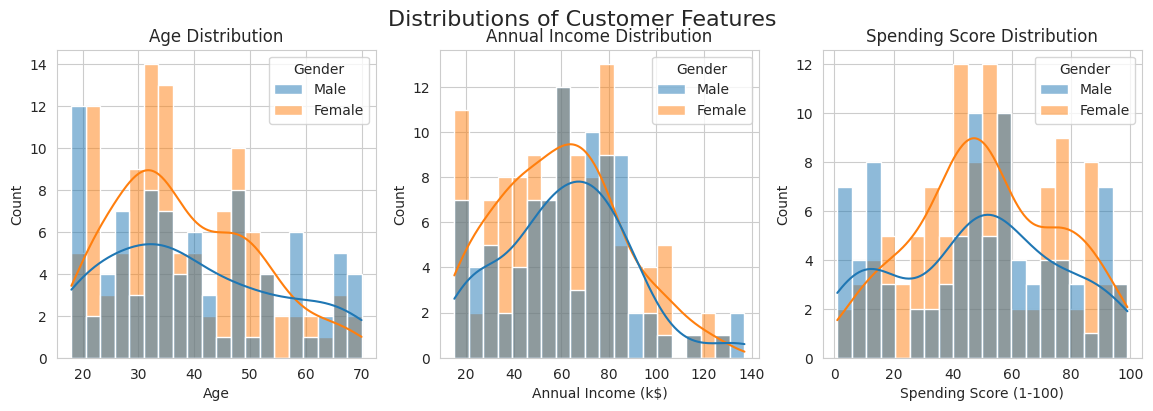

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distributions of Customer Features', fontsize=16)

sns.histplot(ax=axes[0], data=df, x='Age', kde=True, bins=20, hue='Gender').set_title('Age Distribution')
sns.histplot(ax=axes[1], data=df, x='Annual Income (k$)', kde=True, bins=20, hue='Gender').set_title('Annual Income Distribution')
sns.histplot(ax=axes[2], data=df, x='Spending Score (1-100)', kde=True, bins=20, hue='Gender').set_title('Spending Score Distribution')

plt.show()

In [ ]:
df.head(2)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81


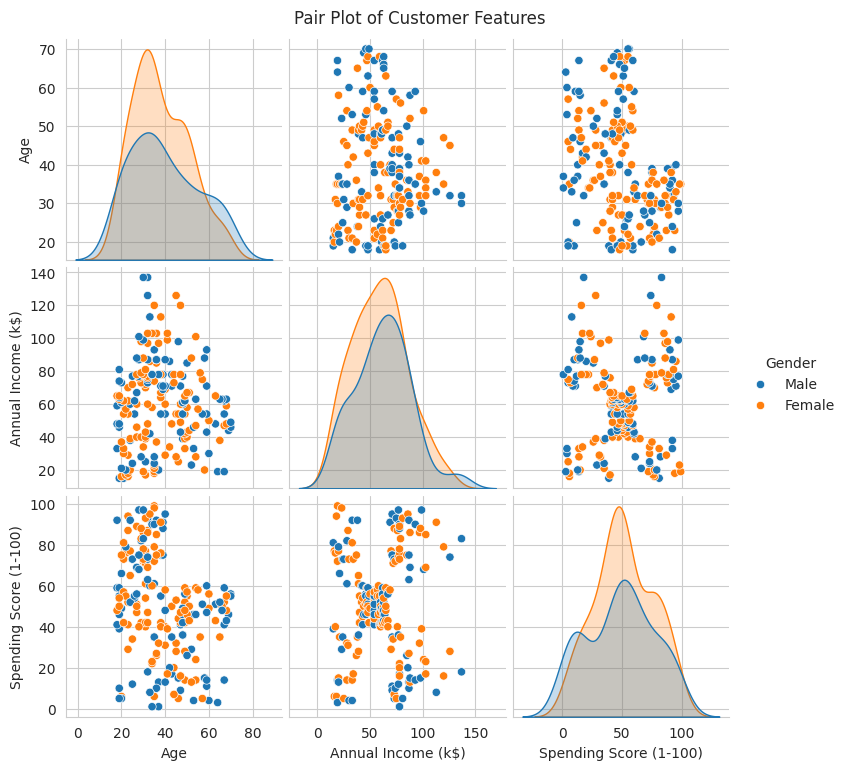

In [ ]:
sns.pairplot(df, vars=['Age','Annual Income (k$)','Spending Score (1-100)'], hue='Gender', diag_kind='kde')
plt.suptitle('Pair Plot of Customer Features', y=1.02)
plt.show()

In [ ]:
fig = px.scatter_3d(
    df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    z='Age',
    color='Gender',
    title='3d Visual'
)

fig.show()

In [ ]:
# 1. Select & Scale the values
X1 = df[['Annual Income (k$)','Spending Score (1-100)']]
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

In [ ]:
# 2. Implement the Elbow Method
wcss1 = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X1_scaled)
    wcss1.append(kmeans.inertia_)

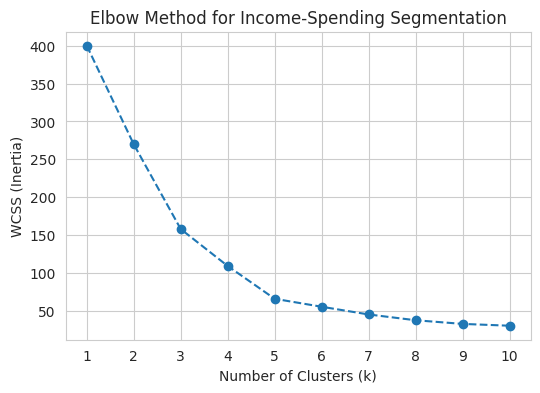

In [ ]:
# 3. Plot the Elbow Curve
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss1, marker='o', linestyle='--')
plt.title('Elbow Method for Income-Spending Segmentation')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

In [ ]:
kmeans1 = KMeans(n_clusters=5,init='k-means++', random_state=42, n_init=10)
df['Income_Cluster'] = kmeans1.fit_predict(X1_scaled)

In [ ]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income_Cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


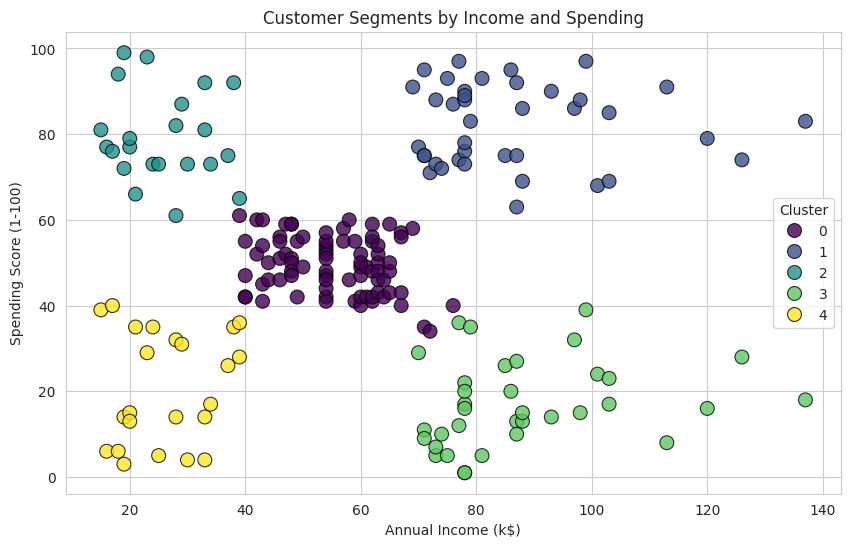

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Income_Cluster', palette='viridis', s=100, alpha=0.8, edgecolor='black')
plt.title('Customer Segments by Income and Spending')
plt.legend(title='Cluster')
plt.show()

In [ ]:
# Quantitative Persona Analysis
cluster_profiles1 = df.groupby('Income_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
cluster_profiles1['Size'] = df['Income_Cluster'].value_counts()
print("--- Income-Based Cluster Profiles ---")
cluster_profiles1

--- Income-Based Cluster Profiles ---


,Age,Annual Income (k$),Spending Score (1-100),Size
Income_Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


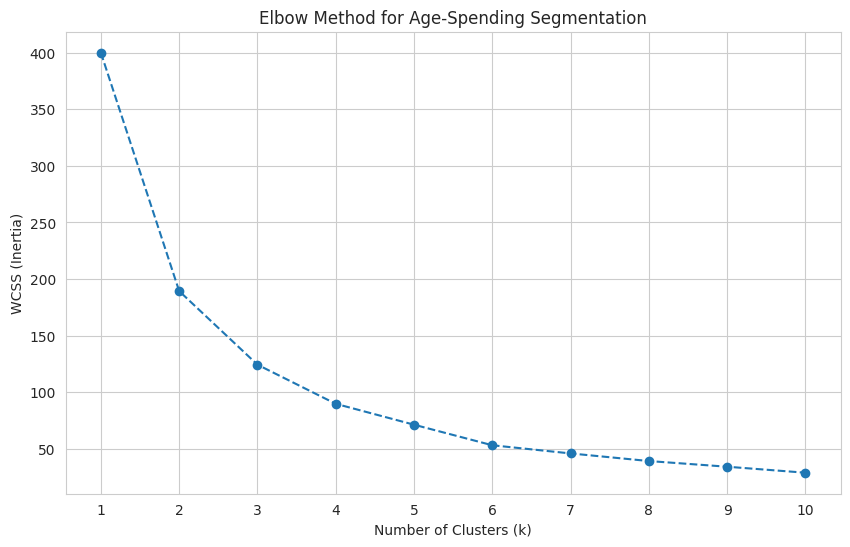

In [ ]:
# 1. Select and scale the features
X2 = df[['Age', 'Spending Score (1-100)']]
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# 2. Implement the Elbow Method
wcss2 = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X2_scaled)
    wcss2.append(kmeans.inertia_)

# 3. Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss2, marker='o', linestyle='--')
plt.title('Elbow Method for Age-Spending Segmentation')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

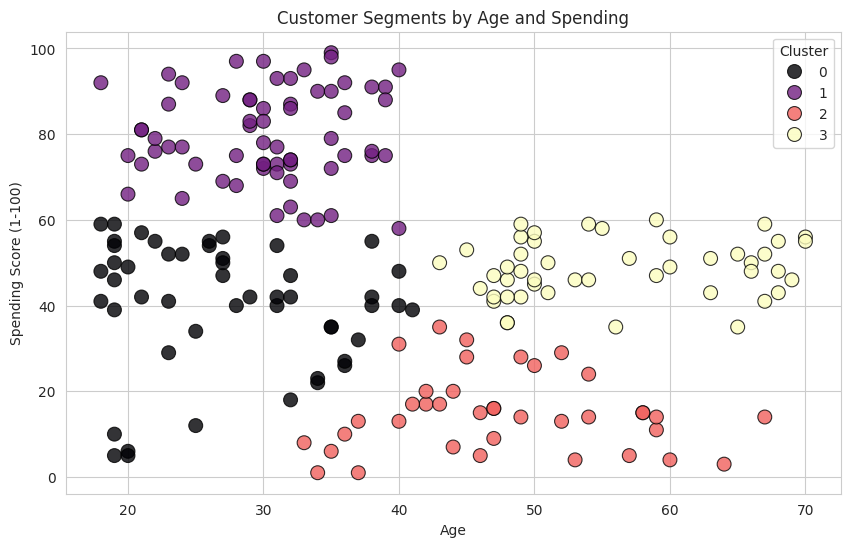

In [ ]:
# Build and fit the final model for age segmentation
kmeans2 = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df['Age_Cluster'] = kmeans2.fit_predict(X2_scaled)

# Visualize the new clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)',
                hue='Age_Cluster', palette='magma', s=100, alpha=0.8, edgecolor='black')
plt.title('Customer Segments by Age and Spending')
plt.legend(title='Cluster')
plt.show()

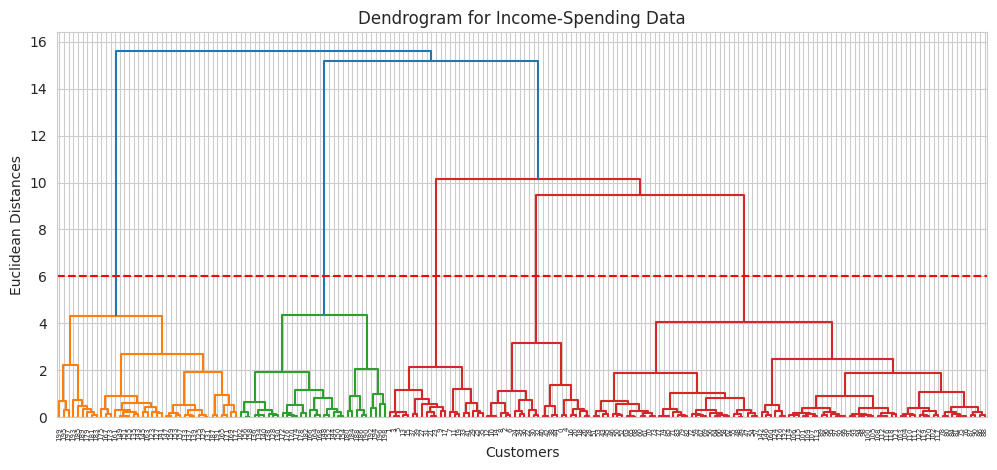

In [ ]:
plt.figure(figsize=(12, 5))
dendrogram = sch.dendrogram(sch.linkage(X1_scaled, method='ward'))
plt.title('Dendrogram for Income-Spending Data')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.axhline(y=6, color='r', linestyle='--') # Example cut-off line
plt.show()

In [ ]:
df.groupby('Gender')['Spending Score (1-100)'].describe()


,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,112.0,51.526786,24.11495,5.0,35.0,50.0,73.0,99.0
Male,88.0,48.511364,27.89677,1.0,24.5,50.0,70.0,97.0


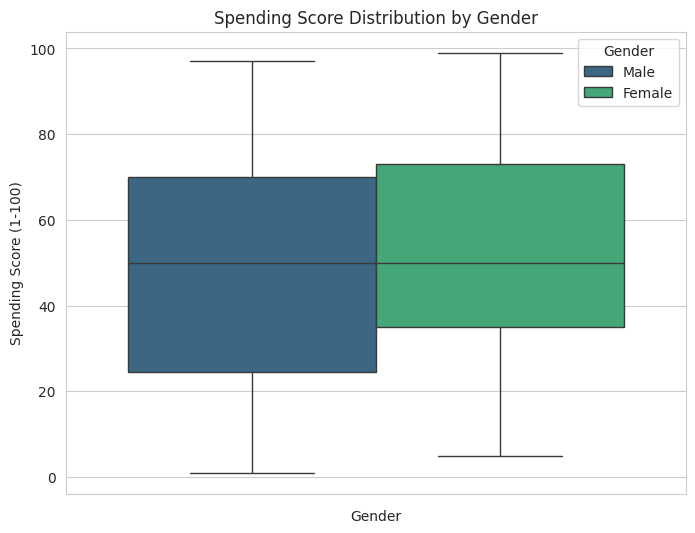

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(hue='Gender', y='Spending Score (1-100)', data=df,palette='viridis')
plt.title('Spending Score Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [ ]:
df['Spending_Income_Ratio'] = df['Spending Score (1-100)'] / df['Annual Income (k$)']

In [ ]:
X3 = df[['Age', 'Spending_Income_Ratio']]
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

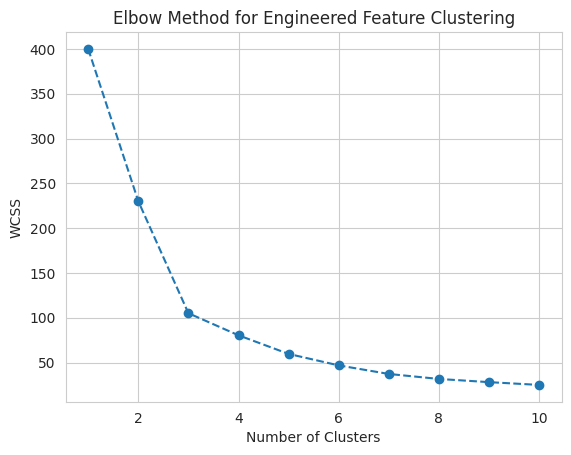

In [ ]:
wcss3 = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X3_scaled)
    wcss3.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss3, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Engineered Feature Clustering')
plt.show()

In [ ]:
kmeans3 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Behavior_Cluster'] = kmeans3.fit_predict(X3_scaled)

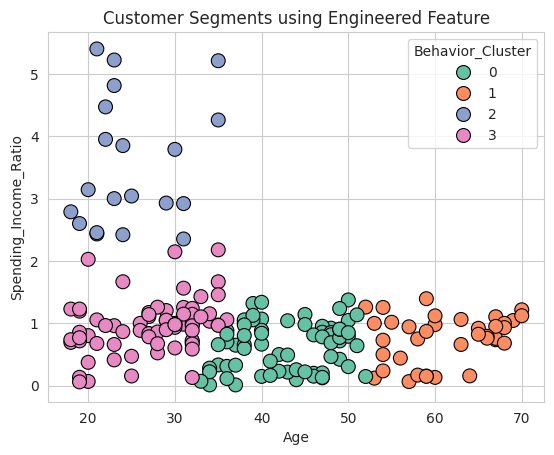

In [ ]:
sns.scatterplot(
    data=df,
    x='Age',
    y='Spending_Income_Ratio',
    hue='Behavior_Cluster',
    palette='Set2',
    s=100,
    edgecolor='black'
)
plt.title('Customer Segments using Engineered Feature')
plt.show()

In [ ]:
df.groupby('Behavior_Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)','Spending_Income_Ratio']].mean().round(2)

,Age,Annual Income (k$),Spending Score (1-100),Spending_Income_Ratio
Behavior_Cluster,,,,
0,42.94,67.93,39.13,0.64
1,61.19,52.84,37.65,0.76
2,24.85,23.00,77.55,3.55
3,27.44,67.70,59.68,0.96


In [ ]:
cluster_profiles = (
    df.groupby('Behavior_Cluster')
      .agg({
          'Age': 'mean',
          'Annual Income (k$)': 'mean',
          'Spending Score (1-100)': 'mean',
          'Spending_Income_Ratio': 'mean'
      })
      .round(2)
)

cluster_profiles['Cluster_Size'] = df['Behavior_Cluster'].value_counts()

print("Cluster Profiles (Engineered Feature Based):")
cluster_profiles

Cluster Profiles (Engineered Feature Based):


,Age,Annual Income (k$),Spending Score (1-100),Spending_Income_Ratio,Cluster_Size
Behavior_Cluster,,,,,
0,42.94,67.93,39.13,0.64,70
1,61.19,52.84,37.65,0.76,37
2,24.85,23.00,77.55,3.55,20
3,27.44,67.70,59.68,0.96,73


In [ ]:
cluster_recommendations = {
    0: {
        "Persona": "Young, Low Income, High Spending Intensity",
        "Strategy": "Flash sales, influencer marketing, budget premium products",
        "Goal": "Increase purchase frequency and brand loyalty"
    },
    1: {
        "Persona": "Young Professionals, Moderate Income & Spending",
        "Strategy": "Bundled offers, EMI options, personalized recommendations",
        "Goal": "Increase average order value"
    },
    2: {
        "Persona": "Middle-Aged, High Income, Controlled Spenders",
        "Strategy": "Premium products, VIP memberships, quality-focused messaging",
        "Goal": "Maximize profit per customer and retention"
    },
    3: {
        "Persona": "Older Customers, Low Spending Intensity",
        "Strategy": "Essential products, senior discounts, trust-based communication",
        "Goal": "Maintain steady revenue and long-term trust"
    }
}

In [ ]:
recommendations_df = pd.DataFrame.from_dict(cluster_recommendations, orient='index')
recommendations_df.index.name = 'Behavior_Cluster'

recommendations_df

,Persona,Strategy,Goal
Behavior_Cluster,,,
0,"Young, Low Income, High Spending Intensity","Flash sales, influencer marketing, budget prem...",Increase purchase frequency and brand loyalty
1,"Young Professionals, Moderate Income & Spending","Bundled offers, EMI options, personalized reco...",Increase average order value
2,"Middle-Aged, High Income, Controlled Spenders","Premium products, VIP memberships, quality-foc...",Maximize profit per customer and retention
3,"Older Customers, Low Spending Intensity","Essential products, senior discounts, trust-ba...",Maintain steady revenue and long-term trust


In [ ]:
final_business_view = cluster_profiles.merge(
    recommendations_df,
    left_index=True,
    right_index=True
)

final_business_view

,Age,Annual Income (k$),Spending Score (1-100),Spending_Income_Ratio,Cluster_Size,Persona,Strategy,Goal
Behavior_Cluster,,,,,,,,
0,42.94,67.93,39.13,0.64,70,"Young, Low Income, High Spending Intensity","Flash sales, influencer marketing, budget prem...",Increase purchase frequency and brand loyalty
1,61.19,52.84,37.65,0.76,37,"Young Professionals, Moderate Income & Spending","Bundled offers, EMI options, personalized reco...",Increase average order value
2,24.85,23.00,77.55,3.55,20,"Middle-Aged, High Income, Controlled Spenders","Premium products, VIP memberships, quality-foc...",Maximize profit per customer and retention
3,27.44,67.70,59.68,0.96,73,"Older Customers, Low Spending Intensity","Essential products, senior discounts, trust-ba...",Maintain steady revenue and long-term trust


In [ ]:
df['Customer_Persona'] = df['Behavior_Cluster'].map(
    recommendations_df['Persona']
)

df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)',
    'Spending_Income_Ratio', 'Behavior_Cluster', 'Customer_Persona']].head()

,Age,Annual Income (k$),Spending Score (1-100),Spending_Income_Ratio,Behavior_Cluster,Customer_Persona
0,19,15,39,2.600000,2,"Middle-Aged, High Income, Controlled Spenders"
1,21,15,81,5.400000,2,"Middle-Aged, High Income, Controlled Spenders"
2,20,16,6,0.375000,3,"Older Customers, Low Spending Intensity"
3,23,16,77,4.812500,2,"Middle-Aged, High Income, Controlled Spenders"
4,31,17,40,2.352941,2,"Middle-Aged, High Income, Controlled Spenders"


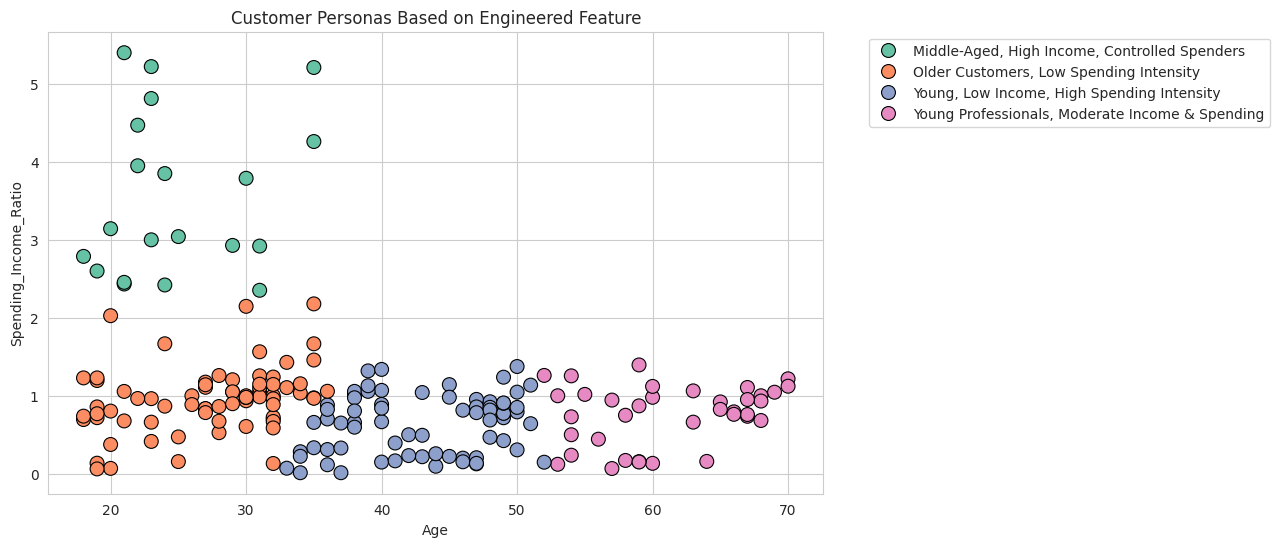

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Spending_Income_Ratio',
    hue='Customer_Persona',
    palette='Set2',
    s=100,
    edgecolor='black'
)
plt.title('Customer Personas Based on Engineered Feature')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()